<a href="https://colab.research.google.com/github/KornelHajto/PEngineersML_msg/blob/main/pengineers_techtogether26_msg_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to the msg Techtogether 2026 task!

In this task you will get familiar with applied machine learning in network traffic management. Machine learning can be utilized in automatic pipelines, for example in an Intrusion Detection System (IDS) in the context of network anomaly detection.

In this Colab notebook you have a Python environment, where code can be run in the cloud. The dataset provided can be used for training and testing the machine learning model.

Your task is to finalize this machine learning solution, **find the mistakes** previously made by a colleague and **fine tune the model parameters** to achive at least **macro 0.75 F1 score** on the test split of the data.

**Your solution will only be accepted and scored, if you present this solution onsite, and reason the engineering decisions you made on the way.**

Understand the given machine learning model, gather the knowledge required too present the solution and answer questions.


Download the dataset

In [ ]:
!gdown 1iv8GYV9bnGV_yx0mDHzpeN0T1dS72XSX

Import dependecies

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, accuracy_score,
    f1_score, roc_auc_score, confusion_matrix
)
from sklearn.utils import class_weight

In [ ]:
!pip install statsmodels

In [ ]:
!pip install imbalanced-learn

The dataset used in this task currently holds network traffic. This dataset is most useful for training supervised machine learning models capable of detecting and even classifying anomalies in the network. In this task scenario, we will simplify the problem, the objective is to achive a simple binary classification into benign and anomaly traffic.

In [ ]:
df = pd.read_csv('train.csv')

print(f"Dataset shape: {df.shape}")
print(f"Total records: {len(df):,}")
print(f"Total features: {df.shape[1]}")

In [ ]:
df.value_counts('label')

In [ ]:
df.head()

In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 1 & 2. Define columns to drop (metadata AND the target column)
columns_to_drop = ['difficulty', 'label']

# Prepare features (X) and explicitly define the Target (y)
X = df.drop(columns=columns_to_drop)
y = df['label']

# Identify categorical columns and one-hot encode them
X = pd.get_dummies(X)

# 4. Encode the target labels (e.g., Benign -> 0, Anomaly -> 1)
benign_label = 'normal' # Change this string to whatever df.value_counts() showed as the safe traffic
y = y.apply(lambda x: 0 if x == benign_label else 1)

# 3. Split the data (changed test_size from 0.6 to 0.2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=333, stratify=y
)

print(f"Training set size: {len(X_train):,} samples")

Training set size: 100,778 samples


In [ ]:
print(f"Original training set shape: {X_train.shape}, {y_train.shape}")
print(f"Original training set class distribution: {pd.Series(y_train).value_counts()}")


### Multi-Class Classification with Multilayer Perceptron (MLP)

In [ ]:
# Install and import TensorFlow/Keras (if not already installed)
!pip install tensorflow

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
import numpy as np

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


#### Data Preprocessing for MLP

In [ ]:
smote = SMOTE(random_state=333)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 2. Initialize the standard scaler
scaler_bin = StandardScaler()

# 3. Fit the scaler on the TRAINING data and transform it
X_train_scaled = scaler_bin.fit_transform(X_train_resampled)

# 4. Transform the TEST data
# CRITICAL: Only use .transform() here, never .fit_transform()!
X_test_scaled = scaler_bin.transform(X_test)

#### Build and Train MLP Model

In [ ]:
# 1. Remove the num_classes variable entirely.

# 2. Define the Binary Classification MLP model
binary_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),

    # Increase the hidden layer size and use 'relu' (2 neurons was far too few)
    Dense(64, activation='relu'),

    # Optional but highly recommended: Add Dropout to prevent overfitting
    Dropout(0.3),

    # Output layer: 1 neuron with 'sigmoid' activation for binary probability
    Dense(1, activation='sigmoid')
])

# 3. Compile
binary_model.compile(
    optimizer='adam', # Changed from the non-existent 'eva'
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')] # Added actual metrics
)

# 4. Train
print("Training Binary Classification Model...")
history = binary_model.fit(
    X_train_scaled,
    y_train_resampled, # Changed from y_train_encoded
    epochs=10,         # Increased from 1 epoch (1 epoch is never enough)
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
print("Training complete!")

Training Binary Classification Model...
Epoch 1/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9750 - loss: 0.0730 - recall: 0.9623 - val_accuracy: 0.9832 - val_loss: 0.0435 - val_recall: 0.9777
Epoch 2/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9894 - loss: 0.0339 - recall: 0.9863 - val_accuracy: 0.9897 - val_loss: 0.0355 - val_recall: 0.9870
Epoch 3/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9912 - loss: 0.0291 - recall: 0.9903 - val_accuracy: 0.9928 - val_loss: 0.0294 - val_recall: 0.9930
Epoch 4/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9920 - loss: 0.0260 - recall: 0.9913 - val_accuracy: 0.9931 - val_loss: 0.0280 - val_recall: 0.9939
Epoch 5/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9925 - loss: 0.0234 - recall: 0.9922 - val_accuracy: 0.9937 - val_loss: 0.0268 - val_recall: 0.9935
Epoch 6/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9930 - loss: 0.0225 - recall: 0.9929 - val_accuracy:

#### Evaluate MLP Model Performance

788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Binary Classification Report:
              precision    recall  f1-score   support

  Benign (0)       1.00      0.99      0.99     13469
 Anomaly (1)       0.99      1.00      0.99     11726

    accuracy                           0.99     25195
   macro avg       0.99      0.99      0.99     25195
weighted avg       0.99      0.99      0.99     25195



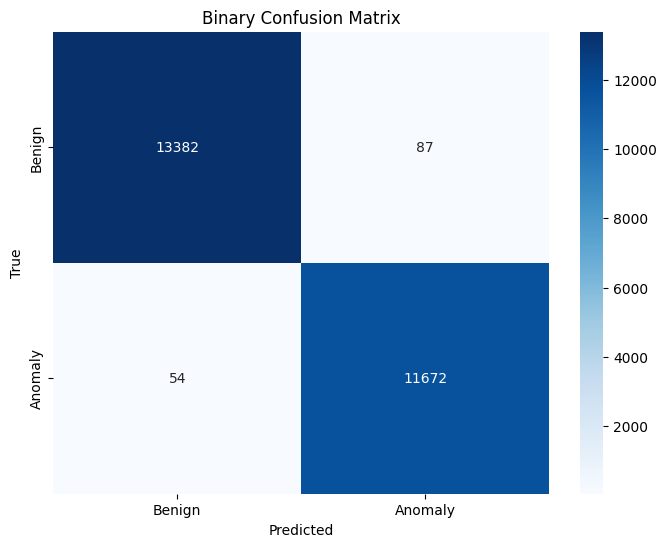

In [ ]:
# 1. Predict probabilities using the SCALED test data
y_pred_probs = binary_model.predict(X_test_scaled)

# 2. Convert probabilities to binary class labels (Threshold at 0.5)
y_pred = (y_pred_probs > 0.5).astype(int)

print("\nBinary Classification Report:")
# 3. Print the classification report (this will show your Macro F1 Score!)
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Anomaly (1)']))

# 4. Generate and display the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6)) # A 2x2 matrix doesn't need a massive 12x10 figure
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Anomaly'],
            yticklabels=['Benign', 'Anomaly'])
plt.title('Binary Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

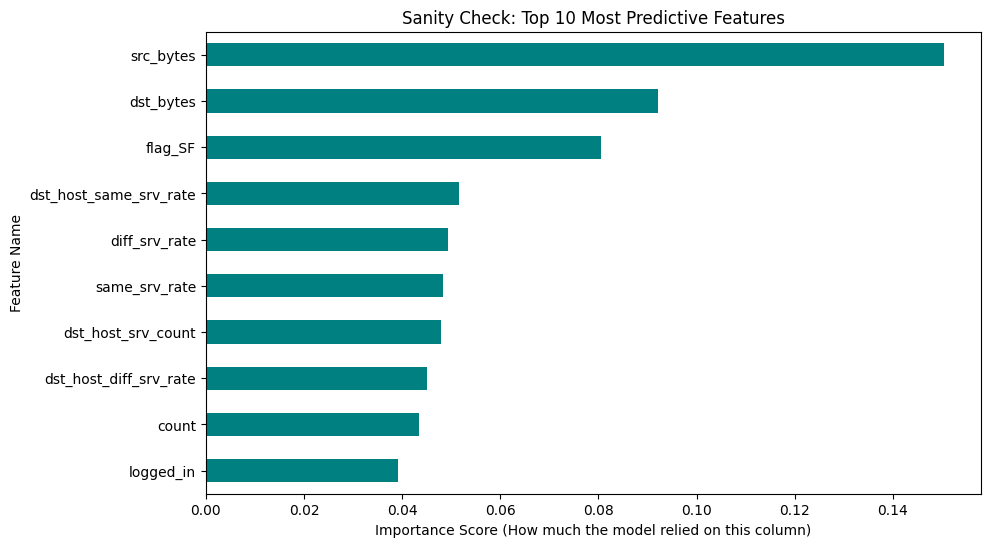

In [ ]:
# 1. Train a quick Random Forest on your balanced data
rf_diagnostic = RandomForestClassifier(n_estimators=100, random_state=333)
rf_diagnostic.fit(X_train_resampled, y_train_resampled)

# 2. Extract and plot the "Feature Importances"
importances = pd.Series(rf_diagnostic.feature_importances_, index=X_train.columns)

plt.figure(figsize=(10, 6))
importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Sanity Check: Top 10 Most Predictive Features')
plt.xlabel('Importance Score (How much the model relied on this column)')
plt.ylabel('Feature Name')
plt.show()